# RSNA Pneumonia — EDA

Stage-0 look at the dataset: class balance, per-patient statistics, image geometry, DICOM metadata distributions (age / sex), and a few sample images with bounding boxes.

Run `python backend/ml/training/fetch_rsna.py` first to populate `backend/ml/data/rsna/`.

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom

DATA_DIR = Path.cwd().resolve().parents[2] / "backend" / "ml" / "data" / "rsna"
TRAIN_IMG_DIR = DATA_DIR / "stage_2_train_images"
TEST_IMG_DIR = DATA_DIR / "stage_2_test_images"

labels = pd.read_csv(DATA_DIR / "stage_2_train_labels.csv")
class_info = pd.read_csv(DATA_DIR / "stage_2_detailed_class_info.csv")

print(f"labels rows        : {len(labels)}")
print(f"class_info rows    : {len(class_info)}")
print(f"unique patientIds  : {labels['patientId'].nunique()}")
print(f"train DICOMs found : {sum(1 for _ in TRAIN_IMG_DIR.glob('*.dcm'))}")
print(f"test DICOMs found  : {sum(1 for _ in TEST_IMG_DIR.glob('*.dcm'))}")
labels.head()

labels rows        : 30227
class_info rows    : 30227
unique patientIds  : 26684
train DICOMs found : 26684
test DICOMs found  : 3000


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


## Binary target distribution (pneumonia vs. not)

`Target=1` rows are bounding boxes; a single patient can contribute multiple rows. Count by patient, not by row.

Target
0    20672
1     6012
Name: count, dtype: int64
positive rate: 0.225


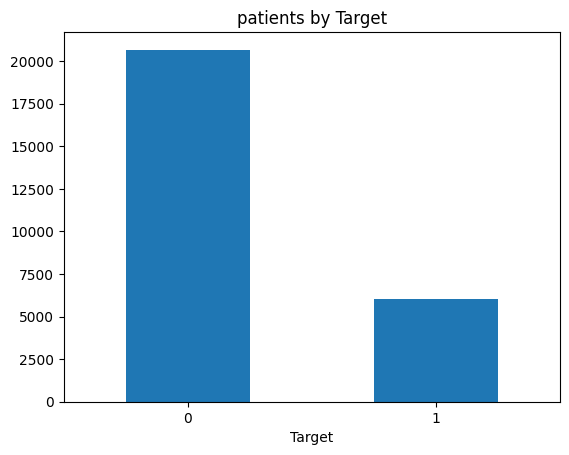

In [9]:
per_patient_target = labels.groupby("patientId")["Target"].max()
counts = per_patient_target.value_counts().sort_index()
print(counts)
print(f"positive rate: {per_patient_target.mean():.3f}")
counts.plot(kind="bar", title="patients by Target", rot=0)
plt.show()

## Detailed class distribution

RSNA splits non-pneumonia into two groups: *Normal* and *No Lung Opacity / Not Normal* (abnormal but not pneumonia). Useful for stratified sampling and for sanity-checking the binary target.

class
No Lung Opacity / Not Normal    11821
Normal                           8851
Lung Opacity                     6012
Name: count, dtype: int64


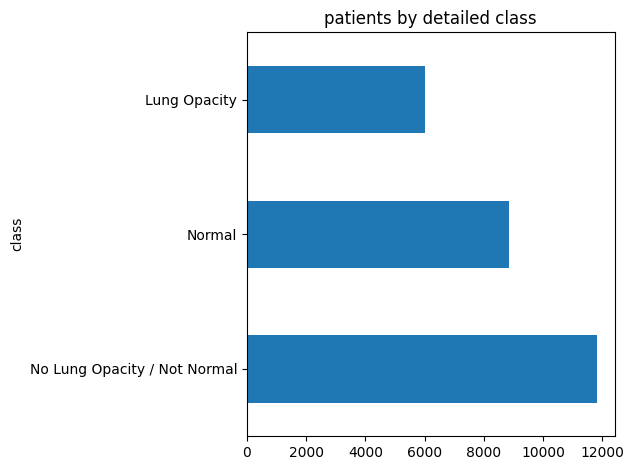

In [10]:
per_patient_class = class_info.drop_duplicates("patientId").set_index("patientId")["class"]
class_counts = per_patient_class.value_counts()
print(class_counts)
class_counts.plot(kind="barh", title="patients by detailed class")
plt.tight_layout()
plt.show()

## DICOM metadata: age, sex, view position

Sample a subset to keep runtime reasonable. The plan's quality bar requires stratifying metrics by age/sex, so we need to confirm the tags are present and reasonably distributed.

In [11]:
SAMPLE_N = 1000
sample_ids = per_patient_target.sample(n=SAMPLE_N, random_state=0).index

records = []
for pid in sample_ids:
    ds = pydicom.dcmread(TRAIN_IMG_DIR / f"{pid}.dcm", stop_before_pixels=True)
    records.append(
        {
            "patientId": pid,
            "age": int(ds.PatientAge) if ds.get("PatientAge") else np.nan,
            "sex": ds.get("PatientSex", "?"),
            "view": ds.get("ViewPosition", "?"),
            "rows": ds.Rows,
            "cols": ds.Columns,
        }
    )

meta = pd.DataFrame(records)
meta.describe(include="all")

,patientId,age,sex,view,rows,cols
count,1000,1000.000000,1000,1000,1000.0,1000.0
unique,1000,NaN,2,2,NaN,NaN
top,dac89109-37cf-4959-b49e-19861fae19a4,NaN,M,PA,NaN,NaN
freq,1,NaN,553,554,NaN,NaN
mean,NaN,47.774000,NaN,NaN,1024.0,1024.0
std,NaN,16.578413,NaN,NaN,0.0,0.0
min,NaN,2.000000,NaN,NaN,1024.0,1024.0
25%,NaN,36.000000,NaN,NaN,1024.0,1024.0
50%,NaN,50.000000,NaN,NaN,1024.0,1024.0
75%,NaN,60.000000,NaN,NaN,1024.0,1024.0


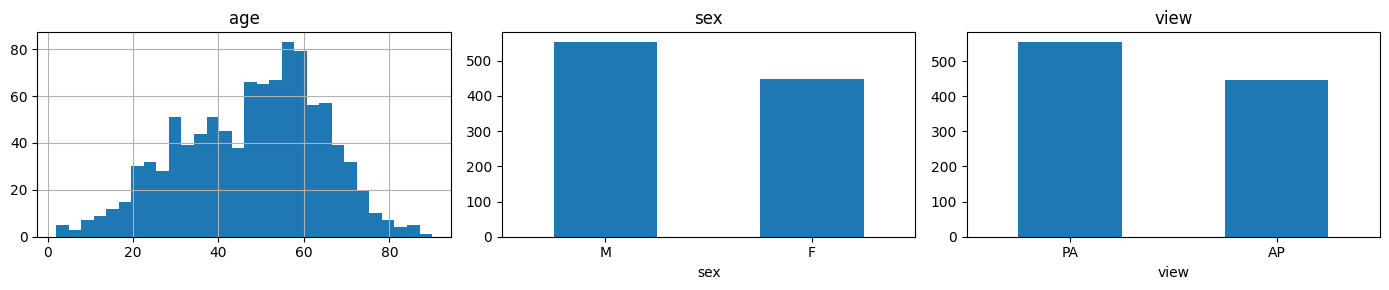

unique image shapes in sample: 1
 rows  cols
 1024  1024


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
meta["age"].hist(bins=30, ax=axes[0]); axes[0].set_title("age")
meta["sex"].value_counts().plot(kind="bar", ax=axes[1], rot=0); axes[1].set_title("sex")
meta["view"].value_counts().plot(kind="bar", ax=axes[2], rot=0); axes[2].set_title("view")
plt.tight_layout()
plt.show()

unique_shapes = meta[["rows", "cols"]].drop_duplicates()
print(f"unique image shapes in sample: {len(unique_shapes)}")
print(unique_shapes.to_string(index=False))

## A few example images

One normal, one pneumonia-positive (with bbox overlay).

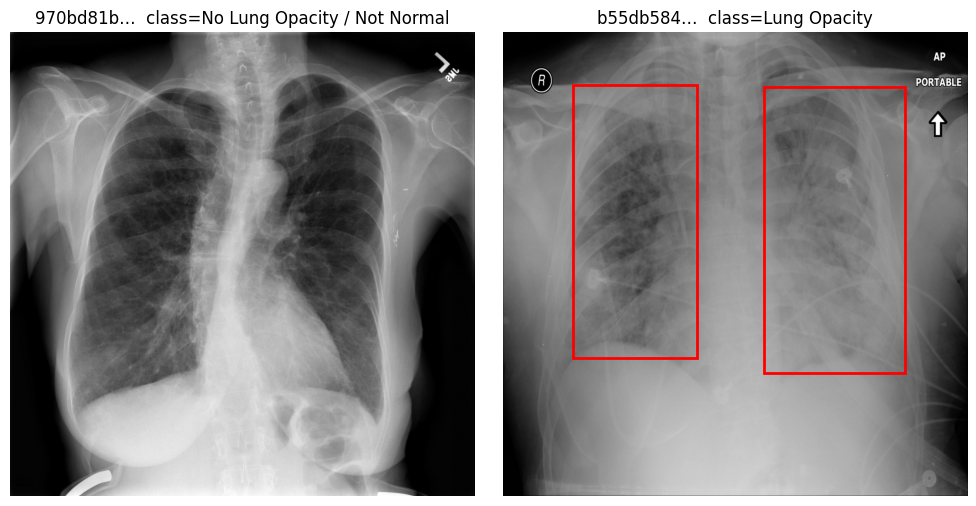

In [13]:
import matplotlib.patches as patches


def show_patient(pid: str, ax: plt.Axes) -> None:
    ds = pydicom.dcmread(TRAIN_IMG_DIR / f"{pid}.dcm")
    ax.imshow(ds.pixel_array, cmap="gray")
    for _, row in labels.query("patientId == @pid and Target == 1").iterrows():
        rect = patches.Rectangle(
            (row.x, row.y), row.width, row.height,
            linewidth=2, edgecolor="red", facecolor="none",
        )
        ax.add_patch(rect)
    klass = per_patient_class.get(pid, "?")
    ax.set_title(f"{pid[:8]}…  class={klass}")
    ax.axis("off")


positive_id = per_patient_target[per_patient_target == 1].sample(1, random_state=0).index[0]
negative_id = per_patient_target[per_patient_target == 0].sample(1, random_state=0).index[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
show_patient(negative_id, axes[0])
show_patient(positive_id, axes[1])
plt.tight_layout()
plt.show()